# 17 — Does vimentin act as a local barrier? Two within-lesion tests

Notebook 16 found no association between a lesion's overall border vimentin and the immune cells around it. That
comparison is weak: lesions differ in age, size, activity and depth. Two sharper tests, each comparing parts of the
**same lesion** (so lesion age, size, activity, animal and image cancel), summarised per animal (unit = animal):

1. **Local border segments.** Each lesion region's edge band (±30 µm) is cut into 100 µm × 100 µm segments. Per
   segment: local vimentin (astrocyte cell vimentin = primary, because the territory measure also picks up vimentin
   of nearby leukocytes; territory as secondary; within-image z), infiltrating immune share just inside (0–30 µm)
   and just outside (0–30 µm and 30–60 µm), active share inside, depth. **Barrier prediction:** within a lesion,
   vimentin-rich stretches of the edge have fewer immune cells outside, given the immune load inside.
2. **Do scarred old lesions stay quiet at relapse?** In relapse animals (PEAK2, PEAK2_MILD, PEAK3): 60 µm patches of
   old fibrotic tissue (S2). Per patch: vimentin of the old tissue itself, and active (S1/S4) cells within 60 µm.
   **Prediction:** within a lesion, vimentin-rich old tissue has less active tissue next to it.

Lesion regions, signed edge distance and depth come from notebook 16 (`data/lesion16/regions.parquet`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, wilcoxon

from beyondboundaries import plotting

plotting.style()
SRC = "notebooks/17_local_barrier.ipynb"
OUT = ROOT / "results" / "17_local_barrier"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
IMMUNE = ["T cell", "B cell", "NK/DC", "DC", "MDM", "Neutrophil"]
SEG = 100.0  # border segment size (µm); 60 µm left too few segments with cells on both sides

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated",
             "x_centroid", "y_centroid"]].copy()
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state", "ctype"]])
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion16" / "regions.parquet"))
obs["immune"] = obs.ctype.isin(IMMUNE)
obs["active"] = obs.lesion_state.str[:2].isin(["S1", "S4"])
obs["old"] = obs.lesion_state.str[:2] == "S2"

fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["section_id", "segmentation_method", "smavim_cell_mean", "smavim_terr_mean"])
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]


def zimg(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


fa["vim_z"] = zimg(fa.smavim_cell_mean, fa.section_id)
fa["terr_vim_z"] = zimg(fa.smavim_terr_mean, fa.section_id)
obs = obs.join(fa[["vim_z", "terr_vim_z"]])
# cells < 20 µm from another tissue piece: no image readouts (pieces touch in runs 1-3)
other = pd.Series(np.inf, index=obs.index)
for _, g in obs.groupby("sample_id", observed=True):
    xy, pc = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if not m.all():
            other[g.index[m]] = cKDTree(xy[~m]).query(xy[m])[0]
obs.loc[other < 20, ["vim_z", "terr_vim_z"]] = np.nan
an = obs.groupby("sample_name", observed=True).agg(stage=("stage", "first"),
                                                   arm=("model", lambda s: "chronic" if str(s.iloc[0]).startswith("CHRONIC") else "RR"))
print(obs.reg.ne("-1").sum(), "cells in or around lesion regions")


def within_unit_partial(df, x, y, covars, unit, min_n=5):
    """Spearman ρ between x and y within each unit after regressing both on covars within that unit."""
    out = {}
    for u, g in df.groupby(unit):
        g = g[[x, y] + covars].dropna()
        if len(g) < min_n:
            continue
        Z = np.c_[np.ones(len(g)), g[covars].to_numpy()]
        rx = g[x].to_numpy() - Z @ np.linalg.lstsq(Z, g[x].to_numpy(), rcond=None)[0]
        ry = g[y].to_numpy() - Z @ np.linalg.lstsq(Z, g[y].to_numpy(), rcond=None)[0]
        if np.std(rx) > 0 and np.std(ry) > 0:
            out[u] = spearmanr(rx, ry).statistic
    return pd.Series(out, dtype=float)


def demean(df, cols, by):
    return df[cols] - df.groupby(by)[cols].transform("mean")

752369 cells in or around lesion regions


## 1. Local border segments

In [3]:
b = obs[(obs.reg != "-1") & obs.reg_dist.between(-60, 30)].copy()
b["seg"] = b.reg + "|" + (b.x_centroid // SEG).astype(int).astype(str) + "_" + (b.y_centroid // SEG).astype(int).astype(str)
ins = b.reg_dist.between(0.01, 30)
out1 = b.reg_dist.between(-30, -0.01)
out2 = b.reg_dist.between(-60, -30)
band = b.reg_dist.between(-30, 30)
seg = pd.DataFrame({
    "reg": b.groupby("seg").reg.first(), "sample_name": b.groupby("seg").sample_name.first(),
    "n_in": b[ins].groupby("seg").size(), "n_out": b[out1].groupby("seg").size(),
    "immune_in": b[ins].groupby("seg").immune.mean(), "immune_out": b[out1].groupby("seg").immune.mean(),
    "immune_out2": b[out2].groupby("seg").immune.mean(), "active_in": b[ins].groupby("seg").active.mean(),
    "vim_tissue": b[band].groupby("seg").terr_vim_z.median(),
    "vim_astro": b[band & (b.Anno_L1_curated == "Astrocyte")].groupby("seg").vim_z.median(),
    "n_astro": b[band & (b.Anno_L1_curated == "Astrocyte")].groupby("seg").size(),
    "depth": b[band].groupby("seg").depth_um.median(),
})
seg = seg[(seg.n_in >= 5) & (seg.n_out >= 5)].copy()
seg["log_depth"] = np.log1p(seg.depth)
seg = seg.join(an, on="sample_name")
seg.to_csv(OUT / "border_segments.csv")
nper = seg.groupby("reg").size()
seg = seg[seg.reg.map(nper) >= 3]
print(f"{len(seg)} border segments in {seg.reg.nunique()} lesion regions, {seg.sample_name.nunique()} animals; "
      f"median {seg.groupby('reg').size().median():.0f} segments per region")

3188 border segments in 392 lesion regions, 53 animals; median 5 segments per region


Within each lesion region, segment variables are centred on the region mean (region fixed effect). Then per animal:
partial Spearman ρ between local vimentin and the outside immune share, adjusting for the inside immune share, inside
active share and log depth. Wilcoxon of per-animal ρ against 0. Negative = barrier-like.

In [4]:
cols = ["vim_tissue", "vim_astro", "immune_in", "immune_out", "immune_out2", "active_in", "log_depth"]
segc = seg.copy()
segc[cols] = demean(seg, cols, "reg")
rows = []
for v in ["vim_tissue", "vim_astro"]:
    for y in ["immune_out", "immune_out2"]:
        r = within_unit_partial(segc, v, y, ["immune_in", "active_in", "log_depth"], "sample_name", min_n=6).dropna()
        rows.append(dict(vimentin=v, outcome=y + (" (0–30 µm outside)" if y == "immune_out" else " (30–60 µm outside)"),
                         animals=len(r), median_rho=r.median(), share_negative=(r < 0).mean(),
                         wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan))
seg_res = pd.DataFrame(rows)
seg_res.to_csv(OUT / "segment_test.csv", index=False)
seg_res.round(3)

/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for u, g in df.groupby(unit):
/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for u, g in df.groupby(unit):
/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for u, g in df.groupby(unit):
/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=F

,vimentin,outcome,animals,median_rho,share_negative,wilcoxon_p
0,vim_tissue,immune_out (0–30 µm outside),51,0.069,0.412,0.048
1,vim_tissue,immune_out2 (30–60 µm outside),49,0.005,0.490,0.313
2,vim_astro,immune_out (0–30 µm outside),49,0.035,0.388,0.122
3,vim_astro,immune_out2 (30–60 µm outside),45,0.018,0.489,0.647


/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for u, g in df.groupby(unit):


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/17_local_barrier/segment_barrier_test.png')

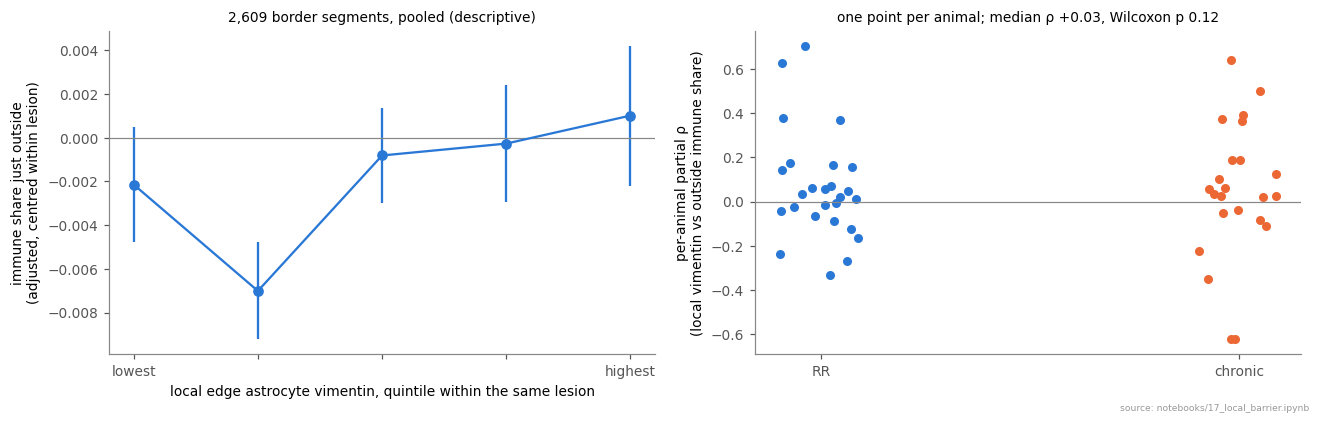

In [5]:
# pooled view (all segments, region-centred): outside immune share by within-region vimentin quintile,
# after adjusting for inside immune share, activity and depth
Z = np.c_[np.ones(len(segc)), segc[["immune_in", "active_in", "log_depth"]].fillna(0).to_numpy()]
ok = segc.vim_astro.notna()
resid = segc.immune_out - Z @ np.linalg.lstsq(Z, segc.immune_out.fillna(0).to_numpy(), rcond=None)[0]
q = pd.qcut(segc.loc[ok, "vim_astro"], 5, labels=False, duplicates="drop")
m = resid[ok].groupby(q).agg(["mean", "sem"])
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
axs[0].errorbar(range(len(m)), m["mean"], m["sem"], marker="o", color=COL[0])
axs[0].axhline(0, color="#888888", lw=0.8)
axs[0].set_xticks(range(len(m)), ["lowest"] + [""] * (len(m) - 2) + ["highest"])
axs[0].set(xlabel="local edge astrocyte vimentin, quintile within the same lesion",
           ylabel="immune share just outside\n(adjusted, centred within lesion)")
axs[0].set_title(f"{len(segc[ok]):,} border segments, pooled (descriptive)", fontsize=9)
r = within_unit_partial(segc, "vim_astro", "immune_out", ["immune_in", "active_in", "log_depth"], "sample_name", 6).dropna()
rr = r.to_frame("rho").join(an)
for k, (arm, g) in enumerate(rr.groupby("arm")):
    axs[1].scatter(np.full(len(g), k) + np.random.default_rng(k).uniform(-0.1, 0.1, len(g)), g.rho, s=24, color=COL[k])
axs[1].axhline(0, color="#888888", lw=0.8)
arms = [arm for arm, _ in rr.groupby("arm")]
axs[1].set_xticks(range(len(arms)), arms)
axs[1].set_ylabel("per-animal partial ρ\n(local vimentin vs outside immune share)")
axs[1].set_title(f"one point per animal; median ρ {r.median():+.2f}, Wilcoxon p {wilcoxon(r).pvalue:.2g}", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "segment_barrier_test", OUT, SRC)

**Immune gradient across the edge**, segments split at their lesion's median local vimentin: if vimentin-rich edges
act as barriers, the immune share should drop more steeply across them.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/17_local_barrier/immune_gradient_by_local_vimentin.png')

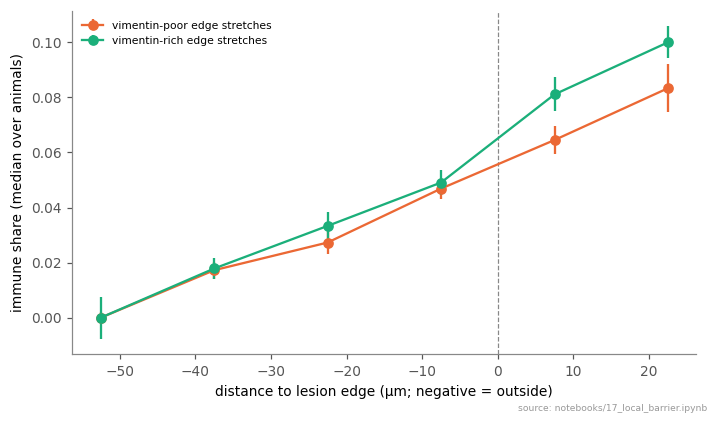

In [6]:
EB = [-60, -45, -30, -15, 0, 15, 30]
bb = b[b.seg.isin(seg.index)].copy()
bb = bb.join(seg[["vim_astro"]].rename(columns={"vim_astro": "seg_vim"}), on="seg")
bb["hi"] = bb.seg_vim > bb.reg.map(seg.groupby("reg").vim_astro.median())
bb["bin"] = pd.cut(bb.reg_dist, EB)
prof = bb.groupby(["sample_name", "hi", "bin"], observed=True).immune.mean().unstack("bin")
mids = [(a_ + b_) / 2 for a_, b_ in zip(EB[:-1], EB[1:])]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for k, (lab, c) in enumerate([("vimentin-poor edge stretches", COL[1]), ("vimentin-rich edge stretches", COL[2])]):
    p = prof.xs(k == 1, level="hi").reindex(columns=bb.bin.cat.categories)
    ax.errorbar(mids, p.median(), p.sem(), marker="o", color=c, label=lab)
ax.axvline(0, color="#888888", ls="--", lw=0.8)
ax.set(xlabel="distance to lesion edge (µm; negative = outside)", ylabel="immune share (median over animals)")
ax.legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "immune_gradient_by_local_vimentin", OUT, SRC)

## 2. Do scarred old lesions stay quiet at relapse?
Relapse animals (PEAK2, PEAK2_MILD, PEAK3). 60 µm patches with ≥ 10 old (S2) cells. Per patch: vimentin of the old
tissue (territory vimentin of the S2 cells; astrocyte vimentin of S2 astrocytes) and the share of active (S1/S4) cells
among all cells within 60 µm of the patch's old cells. Within each lesion region, centred; per animal partial ρ
adjusting for log depth and the patch's old-cell count.

In [7]:
REL = ["PEAK2", "PEAK2_MILD", "PEAK3"]
rel = obs[obs.stage.isin(REL) & (obs.reg != "-1") & (obs.reg_dist > -60)].copy()
rel["patch"] = rel.reg + "|" + (rel.x_centroid // SEG).astype(int).astype(str) + "_" + (rel.y_centroid // SEG).astype(int).astype(str)
rows = []
for pc, g in rel.groupby("meta_sample_id", observed=True):
    allp = obs[(obs.meta_sample_id == pc) & (obs.lesion_state != "not scored")]
    tree = cKDTree(allp[["x_centroid", "y_centroid"]].to_numpy())
    act = allp.active.to_numpy()
    for p, h in g[g.old].groupby("patch"):
        if len(h) < 10:
            continue
        nb = np.unique(np.concatenate(tree.query_ball_point(h[["x_centroid", "y_centroid"]].to_numpy(), 60)))
        rows.append(dict(patch=p, reg=h.reg.iloc[0], sample_name=h.sample_name.iloc[0], n_old=len(h),
                         old_tissue_vim=h.terr_vim_z.median(),
                         old_astro_vim=h[h.Anno_L1_curated == "Astrocyte"].vim_z.median(),
                         active_near=act[nb].mean(), depth=h.depth_um.median()))
op = pd.DataFrame(rows)
op["log_depth"] = np.log1p(op.depth)
op["log_n_old"] = np.log(op.n_old)
op = op[op.reg.map(op.groupby("reg").size()) >= 3]
op.to_csv(OUT / "old_tissue_patches.csv", index=False)
print(f"{len(op)} old-tissue patches in {op.reg.nunique()} lesion regions, {op.sample_name.nunique()} relapse animals")
opc = op.copy()
cc = ["old_tissue_vim", "old_astro_vim", "active_near", "log_depth", "log_n_old"]
opc[cc] = demean(op, cc, "reg")
rows = []
for v in ["old_tissue_vim", "old_astro_vim"]:
    r = within_unit_partial(opc, v, "active_near", ["log_depth", "log_n_old"], "sample_name", min_n=6).dropna()
    rows.append(dict(vimentin=v, animals=len(r), median_rho=r.median(), share_negative=(r < 0).mean(),
                     wilcoxon_p=wilcoxon(r).pvalue if len(r) >= 6 else np.nan, per_animal=r.round(2).to_dict()))
old_res = pd.DataFrame(rows)
old_res.to_csv(OUT / "old_lesion_flare_test.csv", index=False)
old_res

/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


685 old-tissue patches in 51 lesion regions, 9 relapse animals


/Users/christoffer/miniconda3/envs/bb/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,vimentin,animals,median_rho,share_negative,wilcoxon_p,per_animal
0,old_tissue_vim,9,0.160324,0.333333,0.300781,"{'RR_P2M_1': 0.22, 'RR_P2M_2': 0.18, 'RR_P2_3'..."
1,old_astro_vim,9,-0.023393,0.666667,0.359375,"{'RR_P2M_1': 0.04, 'RR_P2M_2': 0.13, 'RR_P2_3'..."


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/17_local_barrier/old_lesion_flare.png')

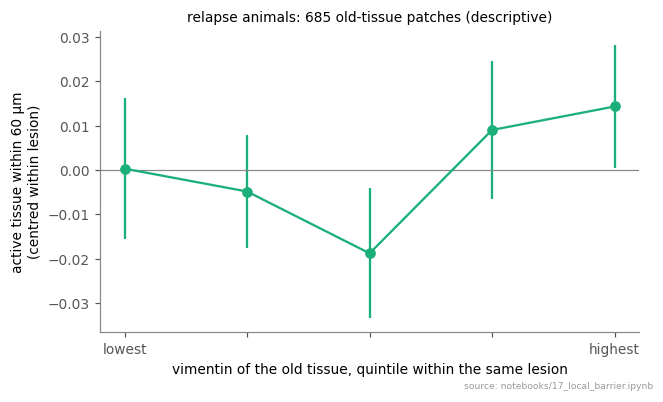

In [8]:
ok = opc.old_tissue_vim.notna()
q = pd.qcut(opc.loc[ok, "old_tissue_vim"], 5, labels=False, duplicates="drop")
m = opc.loc[ok, "active_near"].groupby(q).agg(["mean", "sem"])
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.errorbar(range(len(m)), m["mean"], m["sem"], marker="o", color=COL[2])
ax.axhline(0, color="#888888", lw=0.8)
ax.set_xticks(range(len(m)), ["lowest"] + [""] * (len(m) - 2) + ["highest"])
ax.set(xlabel="vimentin of the old tissue, quintile within the same lesion",
       ylabel="active tissue within 60 µm\n(centred within lesion)")
ax.set_title(f"relapse animals: {ok.sum():,} old-tissue patches (descriptive)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "old_lesion_flare", OUT, SRC)

## How large a barrier effect can we exclude?
Bootstrap (animals resampled, 5000×) of the median per-animal partial ρ for the primary test (astrocyte vimentin vs
immune share 0–30 µm outside). Negative ρ would mean barrier-like.

In [9]:
rng = np.random.default_rng(0)
ci = {}
for v, y in [("vim_astro", "immune_out"), ("vim_tissue", "immune_out")]:
    r = within_unit_partial(segc, v, y, ["immune_in", "active_in", "log_depth"], "sample_name", min_n=6).dropna().to_numpy()
    boots = np.array([np.median(rng.choice(r, len(r))) for _ in range(5000)])
    ci[f"{v} vs {y}"] = dict(animals=len(r), median_rho=np.median(r), ci95_low=np.quantile(boots, 0.025),
                             ci95_high=np.quantile(boots, 0.975))
pd.DataFrame(ci).T.round(3)

/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for u, g in df.groupby(unit):


/tmp/ipykernel_70179/2424651774.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for u, g in df.groupby(unit):


,animals,median_rho,ci95_low,ci95_high
vim_astro vs immune_out,49.0,0.035,-0.016,0.073
vim_tissue vs immune_out,51.0,0.069,-0.023,0.133


## Findings

> **Finding — no sign that astrocyte vimentin acts as a local barrier at the lesion edge.** With 3,188 border segments
> in 392 lesion regions of 53 animals, compared within the same lesion (lesion age, size, activity, animal and image
> cancel) and adjusted for the immune load just inside, local activity and depth, vimentin-rich stretches of the edge
> do **not** have fewer immune cells just outside than vimentin-poor stretches of the same lesion: astrocyte vimentin
> median per-animal ρ +0.035 (p = 0.12; 95 % CI in the table above), 30–60 µm outside +0.018. Territory vimentin
> gives a slightly *positive* link (+0.069, p = 0.05), expected because that measure includes vimentin of the
> leukocytes themselves. A barrier effect of the size that would matter (ρ clearly below 0) is not supported.
>
> **Finding — vimentin-rich old lesions do not stay quieter at relapse.** In relapse animals, old fibrotic tissue
> (685 patches, 51 lesions, 9 animals) with more astrocyte vimentin has as much active tissue next to it as
> vimentin-poor old tissue of the same lesion (median ρ −0.02, p = 0.36).
>
> **Overall answer at this resolution.** Astrocyte vimentin marks lesions in animals that recover (notebooks 11, 15,
> 16: low at peak, highest in mild, never-relapsing and recovery groups, throughout the lesion interior), but neither
> across lesions, nor along the edges of the same lesion, nor in old lesions at relapse does it go with fewer
> immune cells. So in this data vimentin behaves as a **marker of the resolution phase**, not a measurable physical
> barrier to infiltrating immune cells. Caveats: single time points; vimentin pools reactive states; the barrier
> could act on other cells (e.g. microglia, which are excluded here) or be invisible at 100 µm resolution.